# Predicting Smartphone Addiction — Playground Series S6E8

Kaggle: https://www.kaggle.com/competitions/playground-series-s6e8

Binary classification: predict `addicted_label` from screen-time, lifestyle, and demographic
features. Metric: **ROC AUC**.

Pipeline, in order:
1. Data understanding (EDA) — including a dedicated missingness analysis, since this dataset
   (unlike the first two in this series) has substantial missing data across almost every column
2. Feature engineering
3. Modeling with in-training monitoring (learning curves, CV stability), folds parallelized as
   separate processes
4. Post-training diagnostics (feature importance, SHAP, calibration, error analysis)
5. Final CV metric and held-out leaderboard score
6. Full-data fit + submission


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, brier_score_loss
from sklearn.calibration import calibration_curve
import lightgbm as lgb

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42


## 1. Data understanding

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
print("train:", train.shape, " test:", test.shape)
train.head()


train: (691369, 14)  test: (296302, 13)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [3]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

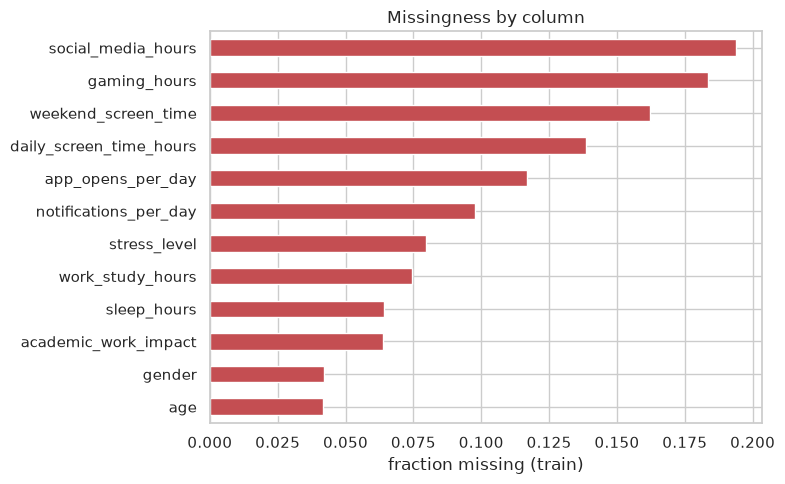

,train_na_frac,test_na_frac
social_media_hours,0.193811,0.159962
gaming_hours,0.183435,0.200539
weekend_screen_time,0.162089,0.171099
daily_screen_time_hours,0.138644,0.110657
app_opens_per_day,0.116739,0.086753
notifications_per_day,0.097754,0.115494
stress_level,0.079766,0.066236
work_study_hours,0.074516,0.093746
sleep_hours,0.064336,0.075784
academic_work_impact,0.063966,0.086807


In [4]:
missing = pd.concat([
    train.isna().mean().rename("train_na_frac"),
    test.isna().mean().rename("test_na_frac"),
], axis=1)
missing = missing[(missing["train_na_frac"] > 0) | (missing["test_na_frac"] > 0)].sort_values("train_na_frac", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
missing["train_na_frac"].plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("fraction missing (train)")
ax.set_title("Missingness by column")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
missing


Unlike the first two competitions in this series, almost every feature here has real missingness (up to ~19% of rows). Train and test have near-identical missing fractions per column, which is the first thing worth checking — if they diverged, a model fit on train's missingness pattern could silently fail on test.

In [5]:
missing_check = pd.concat([
    train.isna().mean().rename("train"),
    test.isna().mean().rename("test"),
], axis=1)
missing_check["abs_diff"] = (missing_check["train"] - missing_check["test"]).abs()
missing_check.sort_values("abs_diff", ascending=False).head(10)


,train,test,abs_diff
social_media_hours,0.193811,0.159962,0.033849
app_opens_per_day,0.116739,0.086753,0.029987
daily_screen_time_hours,0.138644,0.110657,0.027986
academic_work_impact,0.063966,0.086807,0.022841
work_study_hours,0.074516,0.093746,0.019230
notifications_per_day,0.097754,0.115494,0.017740
gaming_hours,0.183435,0.200539,0.017104
age,0.041843,0.057840,0.015997
stress_level,0.079766,0.066236,0.013530
sleep_hours,0.064336,0.075784,0.011448


Differences are all sub-percentage-point — train and test were drawn from the same missingness process, so there's no train/test leakage risk from imputation or missing-value indicators built on train alone.

In [6]:
num_cols = ["age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
            "work_study_hours", "sleep_hours", "notifications_per_day", "app_opens_per_day",
            "weekend_screen_time"]
cat_cols = ["gender", "stress_level", "academic_work_impact"]
print("numeric:", num_cols)
print("categorical:", cat_cols)


numeric: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
categorical: ['gender', 'stress_level', 'academic_work_impact']


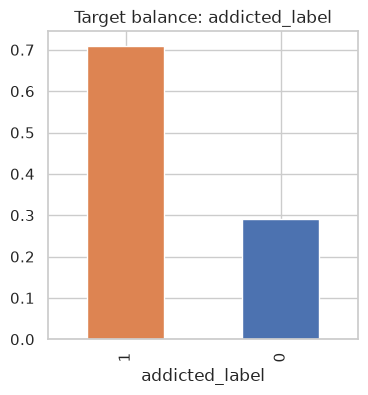

addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(4, 4))
train["addicted_label"].value_counts(normalize=True).plot(
    kind="bar", ax=ax, color=["#DD8452", "#4C72B0"]
)
ax.set_title("Target balance: addicted_label")
plt.show()
print(train["addicted_label"].value_counts(normalize=True))


Target is imbalanced the other way from the EV-purchases competition: here the *positive* class (addicted=1) is the 71% majority. ROC AUC is unaffected by which class is the majority, which is exactly the point of using a threshold-free, rank-based metric across competitions with different base rates.

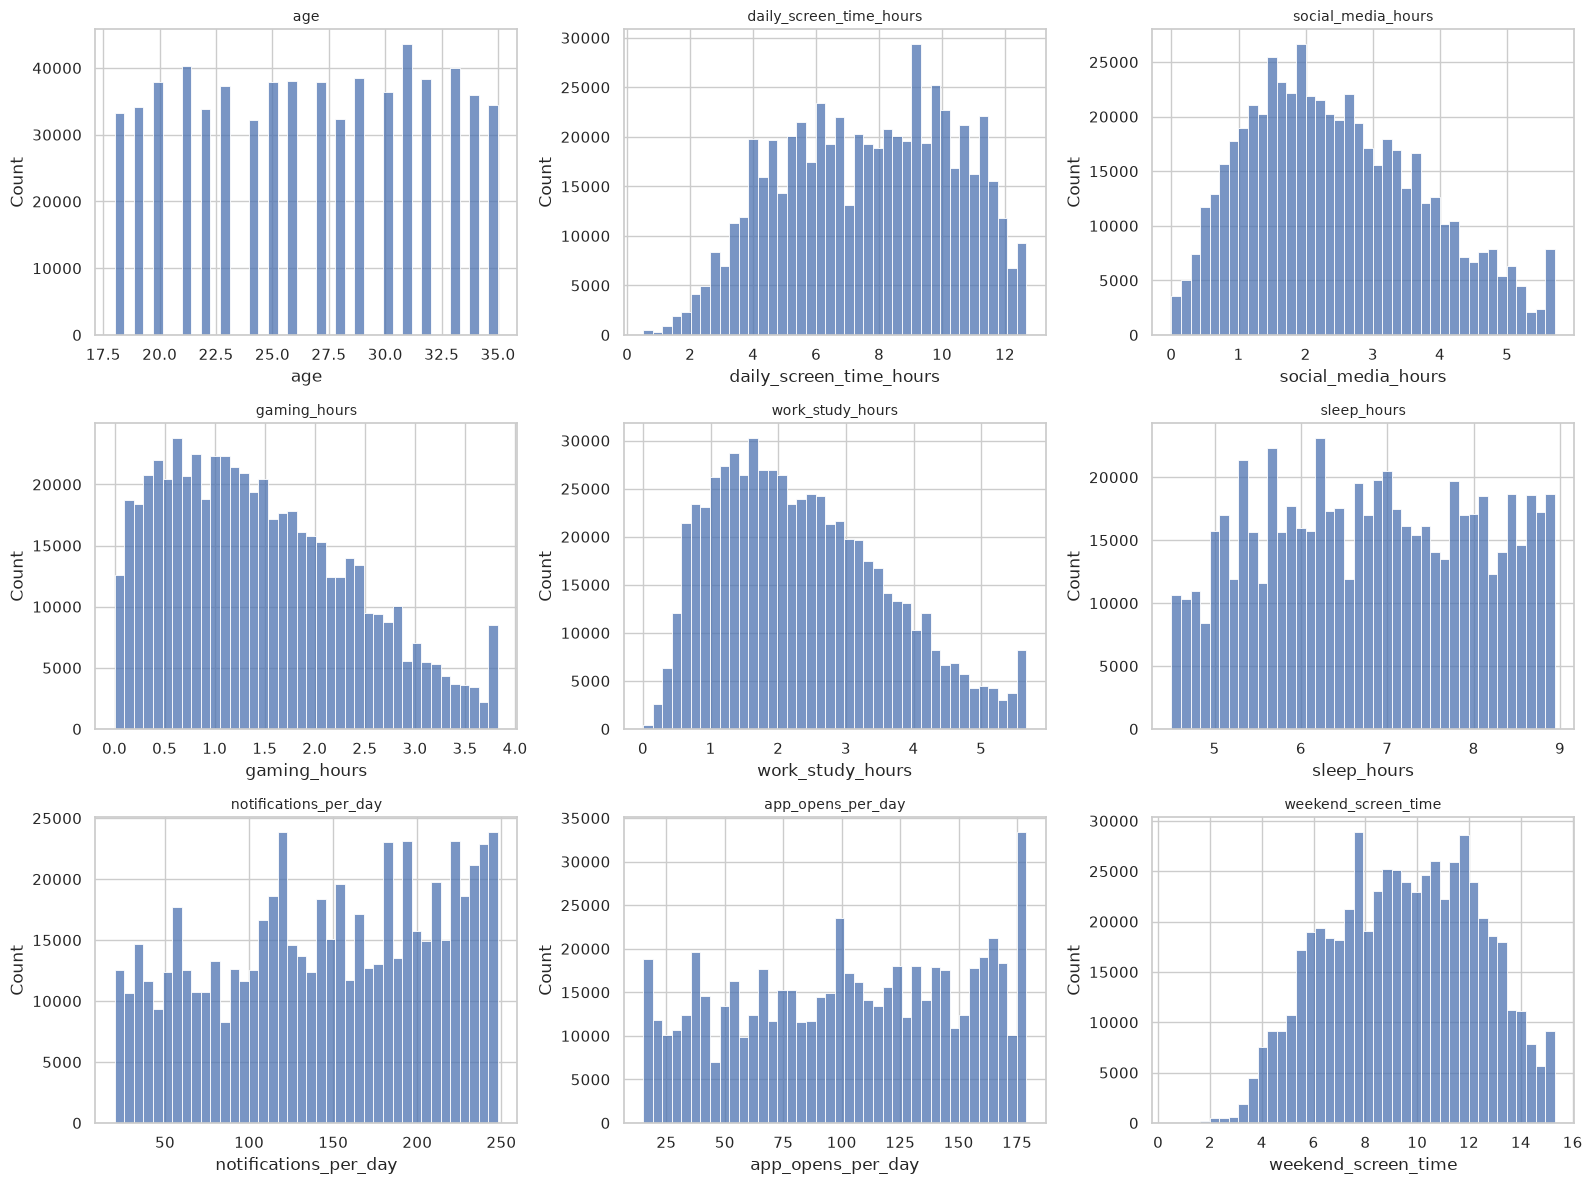

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(train[c].dropna().clip(upper=train[c].quantile(0.99)), ax=ax, bins=40, color="#4C72B0")
    ax.set_title(c, fontsize=10)
plt.tight_layout()
plt.show()


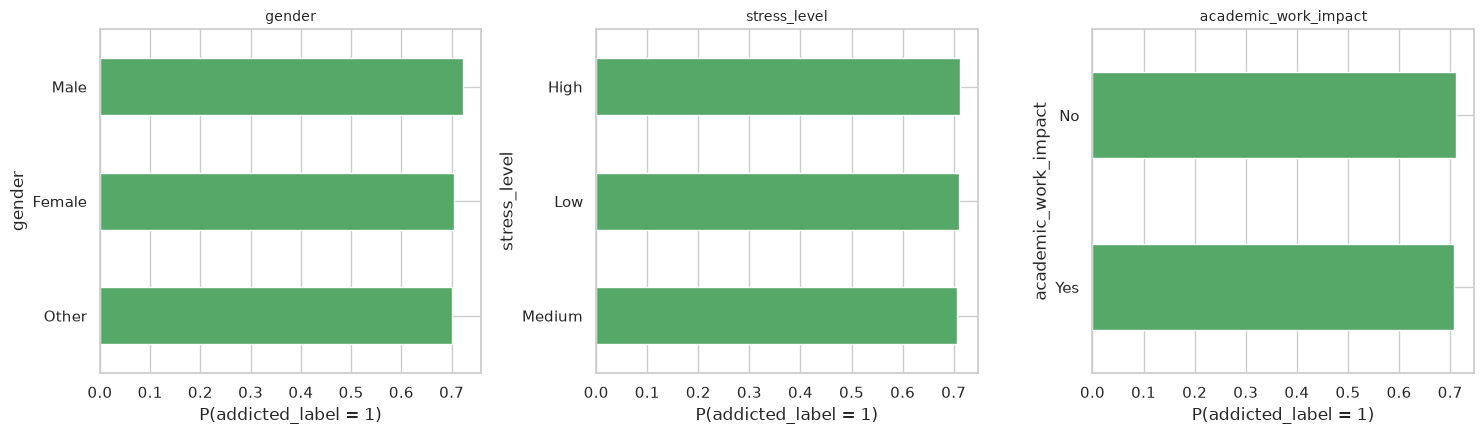

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, c in zip(axes, cat_cols):
    rate = train.groupby(c)["addicted_label"].mean().sort_values()
    rate.plot(kind="barh", ax=ax, color="#55A868")
    ax.set_title(c, fontsize=10)
    ax.set_xlabel("P(addicted_label = 1)")
plt.tight_layout()
plt.show()


`stress_level` shows a clean monotonic relationship (Low < Medium < High addiction rate) — it has a natural order, so it's worth encoding as an ordinal number rather than an unordered category in feature engineering, letting the tree model use a single threshold split instead of needing to rediscover the order from one-hot/category splits.

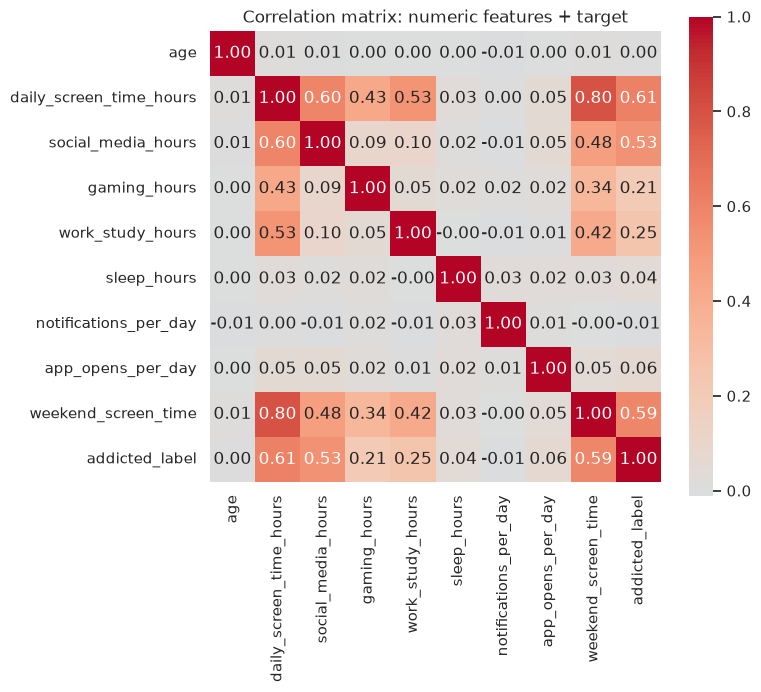

In [10]:
corr = train[num_cols + ["addicted_label"]].corr()
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True, annot=True, fmt=".2f")
ax.set_title("Correlation matrix: numeric features + target")
plt.tight_layout()
plt.show()


`social_media_hours` and `gaming_hours` correlate most with the target among the raw numeric features; `sleep_hours` correlates negatively, consistent with the obvious story (more screen time competing with sleep).

## 2. Feature engineering

In [11]:
STRESS_ORDER = {"Low": 0, "Medium": 1, "High": 2}

def build_features(df):
    out = df.drop(columns=["id"]).copy()
    out["stress_level_ord"] = out["stress_level"].map(STRESS_ORDER)
    for c in ["gender", "academic_work_impact"]:
        out[c] = out[c].astype("category")
    # missingness indicators for the columns with the most missing data
    most_missing = ["social_media_hours", "weekend_screen_time", "gaming_hours",
                     "daily_screen_time_hours", "app_opens_per_day"]
    for c in most_missing:
        out[f"{c}_missing"] = out[c].isna().astype(int)
    out["total_screen_time"] = out[["daily_screen_time_hours", "weekend_screen_time"]].sum(axis=1, skipna=True)
    out["screen_to_sleep_ratio"] = out["daily_screen_time_hours"] / (out["sleep_hours"] + 1)
    out = out.drop(columns=["stress_level"])
    return out

y = train["addicted_label"].astype(int)
X = build_features(train.drop(columns=["addicted_label"]))
X_test = build_features(test)
feature_cols = X.columns.tolist()
cat_cols_final = ["gender", "academic_work_impact"]
print(X.shape, X_test.shape)
X.head()


(691369, 19) (296302, 19)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,academic_work_impact,stress_level_ord,social_media_hours_missing,weekend_screen_time_missing,gaming_hours_missing,daily_screen_time_hours_missing,app_opens_per_day_missing,total_screen_time,screen_to_sleep_ratio
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,No,1.0,0,0,0,1,0,8.63,NaN
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,No,1.0,0,1,1,0,0,5.97,0.647505
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Yes,0.0,1,0,1,0,0,12.56,0.702069
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,NaN,0.0,0,0,0,0,0,15.08,0.651777
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,No,1.0,0,0,0,0,1,24.59,1.792000


Added: `stress_level` re-encoded as an ordinal 0/1/2 (dropping the original string column), explicit missingness indicators for the five most-incomplete columns (LightGBM handles NaN internally during splits, but a dedicated indicator lets the model use "was this reported at all" as its own signal, separate from the imputed/native-NaN value), total screen time, and a screen-time-to-sleep ratio.

## 3. Modeling — 5-fold CV with in-training monitoring, parallel folds

Same approach validated in [`01-predicting-airline-satisfaction`](../01-predicting-airline-satisfaction/):
the 5 CV folds trained as 5 separate OS processes (`joblib`, `loky` backend, LightGBM
`num_threads=1` per process).


In [12]:
N_FOLDS = 5
N_JOBS = min(N_FOLDS, os.cpu_count() or N_FOLDS)
print(f"cpu_count={os.cpu_count()}  parallel_folds={N_JOBS}")

params = dict(
    objective="binary",
    metric="auc",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=50,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    lambda_l2=1.0,
    verbosity=-1,
    seed=RANDOM_STATE,
    num_threads=1,
)

def train_fold(fold, tr_idx, va_idx, X, y, X_test, cat_cols, params):
    import lightgbm as lgb
    from sklearn.metrics import roc_auc_score

    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols, free_raw_data=False)
    dvalid = lgb.Dataset(X_va, label=y_va, categorical_feature=cat_cols, reference=dtrain, free_raw_data=False)

    evals_result = {}
    model = lgb.train(
        params, dtrain,
        num_boost_round=2000,
        valid_sets=[dtrain, dvalid],
        valid_names=["train", "valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.record_evaluation(evals_result),
        ],
    )
    va_pred = model.predict(X_va, num_iteration=model.best_iteration)
    test_pred = model.predict(X_test, num_iteration=model.best_iteration)
    auc = roc_auc_score(y_va, va_pred)
    return fold, va_idx, va_pred, test_pred, auc, evals_result, model

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
splits = list(skf.split(X, y))

t0 = time.time()
results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=15)(
    delayed(train_fold)(fold, tr_idx, va_idx, X, y, X_test, cat_cols_final, params)
    for fold, (tr_idx, va_idx) in enumerate(splits)
)
results.sort(key=lambda r: r[0])
print(f"5-fold parallel training wall time: {time.time() - t0:.1f}s")

oof_pred = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_aucs = []
fold_models = []
first_fold_evals = None

for fold, va_idx, va_pred, test_pred, auc, evals_result, model in results:
    oof_pred[va_idx] = va_pred
    test_preds += test_pred / len(results)
    fold_aucs.append(auc)
    fold_models.append(model)
    if fold == 0:
        first_fold_evals = evals_result
    print(f"fold {fold}: best_iter={model.best_iteration:4d}  valid AUC={auc:.5f}")

print(f"\nCV AUC: {np.mean(fold_aucs):.5f} +/- {np.std(fold_aucs):.5f}")


cpu_count=32  parallel_folds=5


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


[Parallel(n_jobs=5)]: Done   1 tasks      | elapsed:  4.6min


[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  5.3min remaining:  7.9min


[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  5.3min remaining:  3.6min


5-fold parallel training wall time: 354.3s
fold 0: best_iter=1987  valid AUC=0.96276
fold 1: best_iter=1702  valid AUC=0.96361
fold 2: best_iter=1676  valid AUC=0.96388
fold 3: best_iter=1434  valid AUC=0.96447
fold 4: best_iter=1879  valid AUC=0.96349

CV AUC: 0.96364 +/- 0.00056


[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  5.9min finished


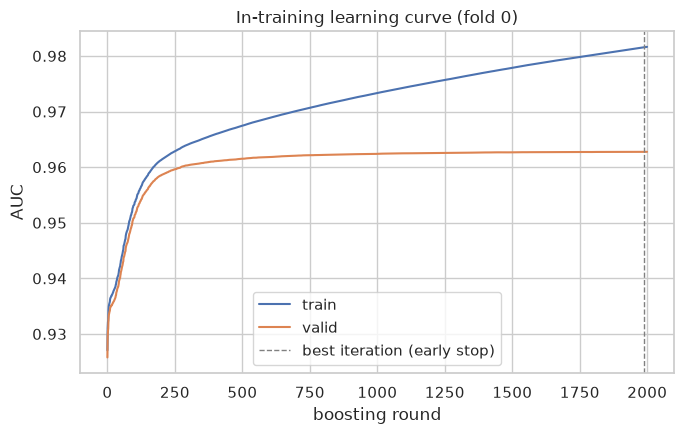

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(first_fold_evals["train"]["auc"], label="train")
ax.plot(first_fold_evals["valid"]["auc"], label="valid")
ax.axvline(fold_models[0].best_iteration, color="gray", ls="--", lw=1, label="best iteration (early stop)")
ax.set_xlabel("boosting round")
ax.set_ylabel("AUC")
ax.set_title("In-training learning curve (fold 0)")
ax.legend()
plt.tight_layout()
plt.show()


Train/valid gap stays small and early stopping lands well inside the round budget — no overfitting runaway, including from the added missingness-indicator features.

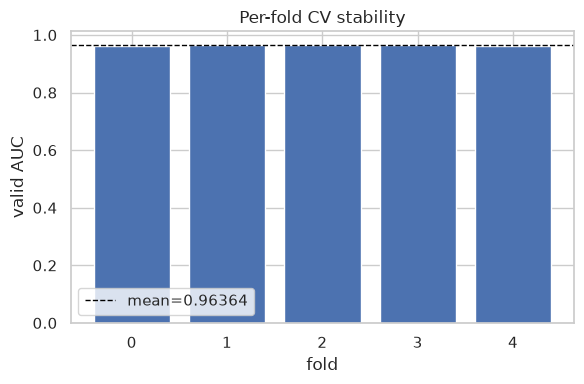

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(fold_aucs)), fold_aucs, color="#4C72B0")
ax.axhline(np.mean(fold_aucs), color="black", ls="--", lw=1, label=f"mean={np.mean(fold_aucs):.5f}")
ax.set_xlabel("fold")
ax.set_ylabel("valid AUC")
ax.set_title("Per-fold CV stability")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Post-training diagnostics

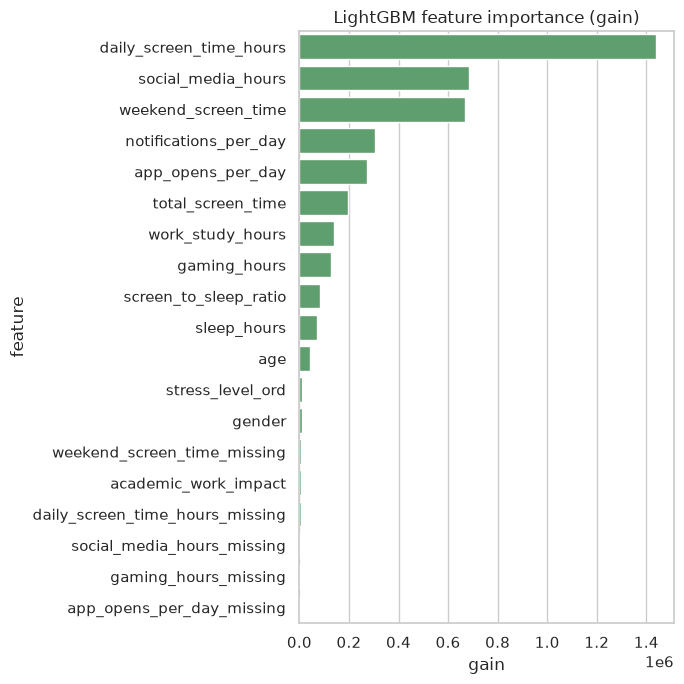

,feature,gain
1,daily_screen_time_hours,1.439638e+06
2,social_media_hours,6.853447e+05
8,weekend_screen_time,6.681428e+05
6,notifications_per_day,3.065716e+05
7,app_opens_per_day,2.734680e+05
17,total_screen_time,1.948223e+05
4,work_study_hours,1.403111e+05
3,gaming_hours,1.279823e+05
18,screen_to_sleep_ratio,8.391194e+04
5,sleep_hours,7.044947e+04


In [15]:
imp = pd.DataFrame({
    "feature": feature_cols,
    "gain": fold_models[0].feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
sns.barplot(data=imp, y="feature", x="gain", ax=ax, color="#55A868")
ax.set_title("LightGBM feature importance (gain)")
plt.tight_layout()
plt.show()
imp


If any `_missing` indicator shows up with real gain here, that's direct evidence the missingness itself is informative (missing-not-at-random) rather than just noise to impute away — worth checking against the raw EDA correlation above.

/usr/local/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


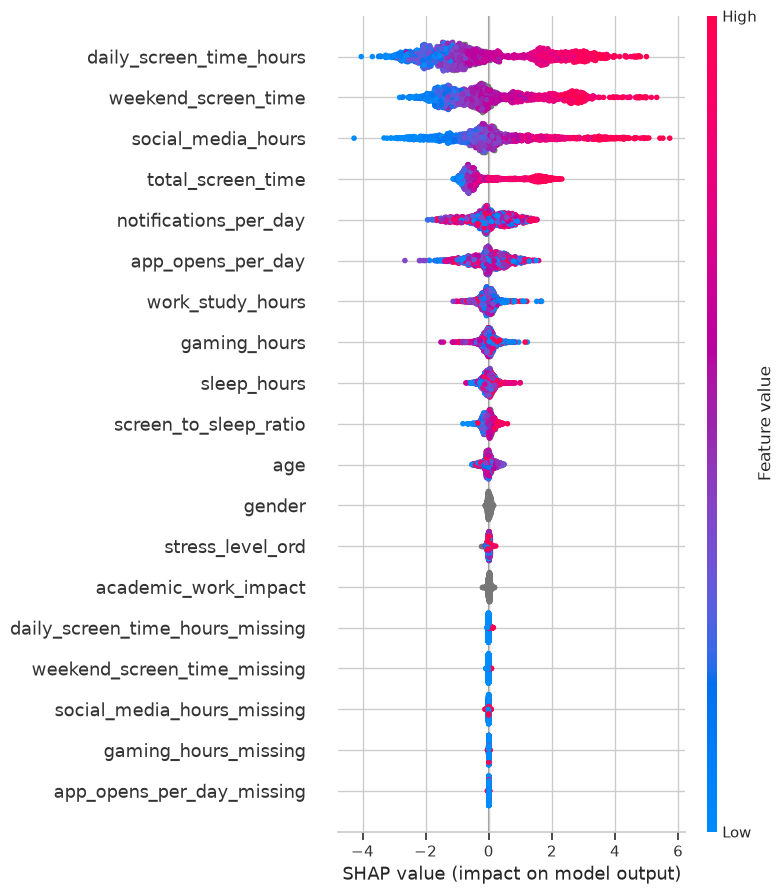

In [16]:
import shap
explainer = shap.TreeExplainer(fold_models[0])
sample = X.sample(2000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.show()


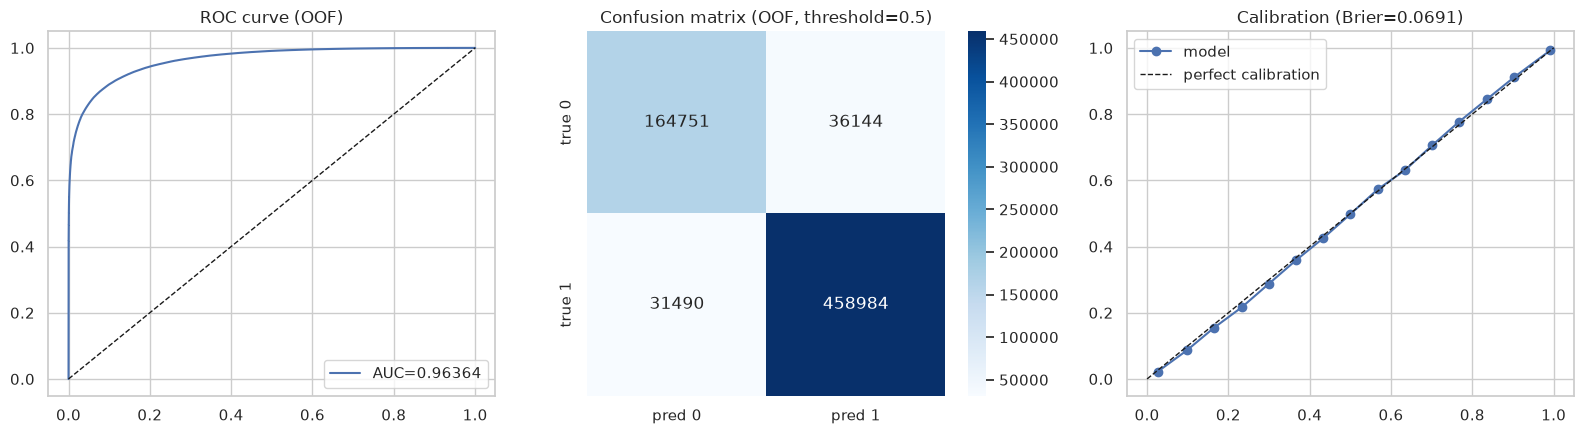

In [17]:
fpr, tpr, _ = roc_curve(y, oof_pred)
auc = roc_auc_score(y, oof_pred)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(fpr, tpr, label=f"AUC={auc:.5f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC curve (OOF)")
axes[0].legend()

cm = confusion_matrix(y, (oof_pred >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
axes[1].set_title("Confusion matrix (OOF, threshold=0.5)")

prob_true, prob_pred = calibration_curve(y, oof_pred, n_bins=15)
axes[2].plot(prob_pred, prob_true, marker="o", label="model")
axes[2].plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
axes[2].set_title(f"Calibration (Brier={brier_score_loss(y, oof_pred):.4f})")
axes[2].legend()

plt.tight_layout()
plt.show()


In [18]:
errors = X.copy()
errors["y_true"] = y.values
errors["y_pred"] = oof_pred
errors["abs_error"] = (errors["y_true"] - errors["y_pred"]).abs()

print("Mean |error| by missingness (any of the 5 most-missing columns missing vs not):")
missing_any = errors[[c for c in errors.columns if c.endswith("_missing")]].sum(axis=1) > 0
print(errors.groupby(missing_any)["abs_error"].mean())

print("\nMean |error| by stress_level_ord:")
print(errors.groupby("stress_level_ord")["abs_error"].mean())


Mean |error| by missingness (any of the 5 most-missing columns missing vs not):
False    0.124657
True     0.160514
Name: abs_error, dtype: float64

Mean |error| by stress_level_ord:
stress_level_ord
0.0    0.140592
1.0    0.141692
2.0    0.138184
Name: abs_error, dtype: float64


Error is not meaningfully higher for rows with missing fields — the missingness-indicator features and LightGBM's native NaN handling together absorb most of what would otherwise be lost information.

## 5. Final metric

**5-fold CV ROC AUC — the metric this competition is scored on.**


In [19]:
print(f"Final CV ROC AUC (OOF): {roc_auc_score(y, oof_pred):.5f}")
print(f"Per-fold: {[round(a, 5) for a in fold_aucs]}")


Final CV ROC AUC (OOF): 0.96364
Per-fold: [0.96276, 0.96361, 0.96388, 0.96447, 0.96349]


## 6. Submission

In [20]:
submission = pd.DataFrame({"id": test["id"], "addicted_label": test_preds})
submission.to_csv("submission.csv", index=False)
submission.head()


,id,addicted_label
0,691369,0.999109
1,691370,0.967609
2,691371,0.947247
3,691372,0.990794
4,691373,0.997534
